In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import json
import plotly.express as px
from dash import Dash, dcc, html

In [2]:
pd.set_option("display.max_columns", None)

## 1. Read and clean the data

In [3]:
# Read the data and save it as original
df_original = pd.read_csv('movies.csv')

In [4]:
# Read the structure of the data
df_original.info()

df_original.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   object 
 3   homepage              1712 non-null   object 
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   object 
 6   original_language     4803 non-null   object 
 7   original_title        4803 non-null   object 
 8   overview              4800 non-null   object 
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   object 
 11  production_countries  4803 non-null   object 
 12  release_date          4802 non-null   object 
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15  spoken_languages     

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton
5,5,258000000,Fantasy Action Adventure,http://www.sonypictures.com/movies/spider-man3/,559,dual identity amnesia sandstorm love of one's ...,en,Spider-Man 3,The seemingly invincible Spider-Man goes up ag...,115.699814,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-01,890871626,139.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,The battle within.,Spider-Man 3,5.9,3576,Tobey Maguire Kirsten Dunst James Franco Thoma...,"[{'name': 'Francine Maisler', 'gender': 1, 'de...",Sam Raimi
6,6,260000000,Animation Family,http://disney.go.com/disneypictures/tangled/,38757,hostage magic horse fairy tale musical,en,Tangled,When the kingdom's most wan

In [5]:
df_original.shape

(4803, 24)

In [6]:
df = df_original

In [7]:
# Now we need to check if we can use id column as primary key column. 
# Because of the first we need to check if all rows are unique

isColumnUnique = df["id"].is_unique

isColumnUnique

True

In [8]:
# After the check above, we can be sure that it is safe to use the id column as the primary key column

df.set_index('id', inplace=True)

In [9]:
# We should remove index, because this column doesn't bring us any useful inform
df.drop(columns=["index"], axis=1, inplace=True)

In [10]:
df

,budget,genres,homepage,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
id,,,,,,,,,,,,,,,,,,,,,,
19995,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
285,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
206647,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
49026,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
49529,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9367,220000,Action Crime Thriller,NaN,united states\u2013mexico barrier legs arms pa...,es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,"[{""name"": ""Columbia Pictures"", ""id"": 5}]","[{""iso_3166_1"": ""MX"", ""name"": ""Mexico""}, {""iso...",1992-09-04,2040920,81.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,"He didn't come looking for trouble, but troubl...",El Mariachi,6.6,238,Carlos Gallardo Jaime de Hoyos Peter Marquardt...,"[{'name': 'Robert Rodriguez', 'gender': 0, 'de...",Robert Rodriguez
72766,9000,Comedy Romance,NaN,NaN,en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.64255

In [11]:
# Now we need to check the types of the columns

df.dtypes

budget                    int64
genres                   object
homepage                 object
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
cast                     object
crew                     object
director                 object
dtype: object

In [12]:
# We see the problem with the column 'release_date', it should be of type datetime64[ns]

# 1. Inspect the raw value
first_row_date = df.iloc[0, df.columns.get_loc('release_date')]
print(f"Raw value example (repr): {repr(first_row_date)}")

# 2. Define the regex pattern
regex_pattern = r"^(?:\d{4})-(0[1-9]|1[0-2])-(0[1-9]|[12]\d|3[01])$"

# 3. Create the mask and handle NaN values
# We use na=False so that any missing/null values are treated as False (not matching)
mask = df["release_date"].str.match(regex_pattern, na=False)

# 4. Count valid and invalid rows
# Now mask contains only True or False, so ~ will work perfectly
valid_count = mask.sum()
invalid_count = (~mask).sum()

print("-" * 40)
print(f"Valid format rows:   {valid_count}")
print(f"Invalid format rows: {invalid_count}")
print("-" * 40)

# 5. Preview invalid entries
if invalid_count > 0:
    print("Examples of invalid date entries (including NaNs):")
    print(df.loc[~mask, "release_date"].head())

Raw value example (repr): '2009-12-10'
----------------------------------------
Valid format rows:   4802
Invalid format rows: 1
----------------------------------------
Examples of invalid date entries (including NaNs):
id
380097    NaN
Name: release_date, dtype: object


In [13]:
# The result above shows us that we have problem with the row with id 380097
row_380097 = df.query('id == 380097')
row_380097


,budget,genres,homepage,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
id,,,,,,,,,,,,,,,,,,,,,,
380097,0,NaN,NaN,NaN,en,America Is Still the Place,1971 post civil rights San Francisco seemed li...,0.0,[],[],NaN,0,0.0,[],Released,NaN,America Is Still the Place,0.0,0,NaN,[],NaN


In [14]:
# This record (id: 380097) should be considered for removal or separate handling
# due to a high proportion of missing or unreliable values across key features
# (e.g., genres, homepage, keywords, production companies, crew, and cast).
#
# Such incomplete metadata reduces data consistency and can negatively impact
# statistical analysis and machine learning models that rely on structured inputs.
#
# Additionally, values like budget = 0, revenue = 0, and vote_count = 0,
# combined with missing contextual information, suggest that this entry is not
# comparable to fully populated records in the dataset.
#
# Therefore, it may be treated as a high-missingness record and either excluded
# from core analyses or handled separately depending on the use case.
df.drop(380097, axis= "index", inplace=True)

In [15]:
df["release_date"] = pd.to_datetime(
    df["release_date"],
    format="%Y-%m-%d",
    errors="coerce"
)

In [16]:
# Now the release_date should be of the correct type
df.dtypes

budget                           int64
genres                          object
homepage                        object
keywords                        object
original_language               object
original_title                  object
overview                        object
popularity                     float64
production_companies            object
production_countries            object
release_date            datetime64[ns]
revenue                          int64
runtime                        float64
spoken_languages                object
status                          object
tagline                         object
title                           object
vote_average                   float64
vote_count                       int64
cast                            object
crew                            object
director                        object
dtype: object

In [17]:
# Check if the record is correctly deleted
df.query('id == 380097')

,budget,genres,homepage,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
id,,,,,,,,,,,,,,,,,,,,,,


In [18]:
# Check the count of missing values (NaN) for each column in the dataset.
# isnull() identifies empty cells, and sum() adds them up per column.
null_counts = df.isnull().sum()

print("Missing values per column:")
print(null_counts)

# To see only the columns that actually have missing values:
print("\nColumns with at least one missing value:")
print(null_counts[null_counts > 0])

Missing values per column:
budget                     0
genres                    27
homepage                3090
keywords                 411
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               0
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  843
title                      0
vote_average               0
vote_count                 0
cast                      42
crew                       0
director                  29
dtype: int64

Columns with at least one missing value:
genres        27
homepage    3090
keywords     411
overview       3
runtime        2
tagline      843
cast          42
director      29
dtype: int64


In [19]:
# Let's analyse the results above:
# For the genres is not ok to be empty. Need to be checked
# For the homepage, is ok to be empty; not every move should have a homepage. This column is not really essential
# For keywords need to be checked
# Overview is ok, 3 to be empty, this field is not really essential
# Tagline is also not really essential and is ok to be empty
# Cast and director are essential to not be null, so we need to investigate and make a decision on what to do with them, because later we will need them for visualisations

# For the current state and target of the project, we will not need keywords and tagline, but in the future, when this system grows to a movie-suggesting system, these textual feature fields will be essential

In [20]:
# Create a filter to see rows where any of these critical columns are empty.
# We use .isnull() and the pipe symbol (|) which means "OR".
missing_data_view = df[df['genres'].isnull() | 
                       df['runtime'].isnull() | 
                       df['cast'].isnull() | 
                       df['director'].isnull()]

# Display the first few rows to inspect the patterns.
print(f"Rows {len(missing_data_view)} with missing critical values:")
display(missing_data_view[['title', 'genres', 'runtime', 'cast', 'director']].head(len(missing_data_view)))

Rows 64 with missing critical values:


,title,genres,runtime,cast,director
id,,,,,
17644,Barney's Great Adventure,Family,76.0,NaN,Steve Gomer
370980,Chiamatemi Francesco - Il Papa della gente,Drama,NaN,Rodrigo de la Serna Sergio Hern\u00e1ndez \u00...,Daniele Luchetti
19615,Flying By,Drama,95.0,Billy Ray Cyrus Heather Locklear Ahnaise Chris...,NaN
447027,Running Forever,Family,88.0,NaN,NaN
26379,Paa,Drama Family Foreign,133.0,Amitabh Bachchan Abhishek Bachchan Vidya Balan...,NaN
...,...,...,...,...,...
64973,"Peace, Propaganda & the Promised Land",Documentary,80.0,NaN,Sut Jhally
322745,Counting,Documentary,111.0,NaN,Jem Cohen
174362,Bending Steel,Documentary,93.0,NaN,Dave Carroll


In [21]:
# We need to take decicion for each of the critical missing fields
# For the runtime the best solution in my opinion is to fill na with median value
df['runtime'] = df['runtime'].fillna(df['runtime'].median())

In [22]:
# For the genres, I think the best decision is to fill na values with other. When we make specific visualisation for these fields, we need to remove them
df['genres'] = df['genres'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')

In [23]:
def extract_to_list_safe(column_value):
    # If the value is already a list (sometimes pandas parses them automatically), just return it.
    if isinstance(column_value, list):
        return [item.get('name') for item in column_value if isinstance(item, dict)]
    
    # If it's a string, try to parse it.
    if isinstance(column_value, str) and column_value.strip():
        try:
            # Replace single quotes with double quotes if needed, as JSON requires double quotes.
            valid_json = column_value.replace("'", '"')
            data = json.loads(valid_json)
            return [item['name'] for item in data if 'name' in item]
        except:
            return []
            
    return []

# Applying the updated function
df['production_companies'] = df['production_companies'].apply(extract_to_list_safe)

# Let's check a few rows that actually have data
print(df['production_companies'].head(10))

id
19995     [Ingenious Film Partners, Twentieth Century Fo...
285       [Walt Disney Pictures, Jerry Bruckheimer Films...
206647                     [Columbia Pictures, Danjaq, B24]
49026     [Legendary Pictures, Warner Bros., DC Entertai...
49529                                [Walt Disney Pictures]
559       [Columbia Pictures, Laura Ziskin Productions, ...
38757     [Walt Disney Pictures, Walt Disney Animation S...
99861     [Marvel Studios, Prime Focus, Revolution Sun S...
767                            [Warner Bros., Heyday Films]
209112    [DC Comics, Atlas Entertainment, Warner Bros.,...
Name: production_companies, dtype: object


In [24]:
df

,budget,genres,homepage,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
id,,,,,,,,,,,,,,,,,,,,,,
19995,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
285,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[Walt Disney Pictures, Jerry Bruckheimer Films...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
206647,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[Columbia Pictures, Danjaq, B24]","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
49026,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[Legendary Pictures, Warner Bros., DC Entertai...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
49529,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,[Walt Disney Pictures],"[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9367,220000,Action Crime Thriller,NaN,united states\u2013mexico barrier legs arms pa...,es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,[Columbia Pictures],"[{""iso_3166_1"": ""MX"", ""name"": ""Mexico""}, {""iso...",1992-09-04,2040920,81.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,"He didn't come looking for trouble, but troubl...",El Mariachi,6.6,238,Carlos Gallardo Jaime de Hoyos Peter Marquardt...,"[{'name': 'Robert Rodriguez', 'gender': 0, 'de...",Robert Rodriguez
72766,9000,Comedy Romance,NaN,NaN,en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,[],[],2011-12-26,0,85.0,[],Released,A newlywed couple's honeymoon is upended by th...,Newlyweds,5.9,

In [25]:
# Now we do the same for production_countries, spoken_languages

df['production_countries'] = df['production_countries'].apply(extract_to_list_safe)
df['spoken_languages'] = df['spoken_languages'].apply(extract_to_list_safe)

In [26]:
# Lets see how crew feature looks
first_row_crew = df.iloc[0, df.columns.get_loc('crew')]
first_row_crew

'[{\'name\': \'Stephen E. Rivkin\', \'gender\': 0, \'department\': \'Editing\', \'job\': \'Editor\', \'credit_id\': \'52fe48009251416c750aca23\', \'id\': 1721}, {\'name\': \'Rick Carter\', \'gender\': 2, \'department\': \'Art\', \'job\': \'Production Design\', \'credit_id\': \'539c47ecc3a36810e3001f87\', \'id\': 496}, {\'name\': \'Christopher Boyes\', \'gender\': 0, \'department\': \'Sound\', \'job\': \'Sound Designer\', \'credit_id\': \'54491c89c3a3680fb4001cf7\', \'id\': 900}, {\'name\': \'Christopher Boyes\', \'gender\': 0, \'department\': \'Sound\', \'job\': \'Supervising Sound Editor\', \'credit_id\': \'54491cb70e0a267480001bd0\', \'id\': 900}, {\'name\': \'Mali Finn\', \'gender\': 1, \'department\': \'Production\', \'job\': \'Casting\', \'credit_id\': \'539c4a4cc3a36810c9002101\', \'id\': 1262}, {\'name\': \'James Horner\', \'gender\': 2, \'department\': \'Sound\', \'job\': \'Original Music Composer\', \'credit_id\': \'5544ee3b925141499f0008fc\', \'id\': 1729}, {\'name\': \'James

In [27]:
# Here are several ways to handle crew data. To be easyer for analyze and visualisation, lets separate in different columns the main movie roles. We already have director feature, so we skip it

# Function to extract specific roles from the complex crew list
def extract_crew_roles(crew_data, target_job):
    try:
        # Converting the string representation of list to actual Python list
        crew_list = ast.literal_eval(crew_data)
        # Returning a list of names where the job matches our target
        return [member['name'] for member in crew_list if member['job'] == target_job]
    except:
        return []

# --- Extracting Writers ---
# Writers can have jobs like 'Writer', 'Screenplay', or 'Author'. 
# For simplicity, we'll start with 'Writer'.
df['writers'] = df['crew'].apply(lambda x: extract_crew_roles(x, 'Writer'))

# --- Extracting Producers ---
df['producers'] = df['crew'].apply(lambda x: extract_crew_roles(x, 'Producer'))

# --- Extracting Editors ---
df['editors'] = df['crew'].apply(lambda x: extract_crew_roles(x, 'Editor'))

# --- Extracting Director of Photography (Camera) ---
df['cinematography'] = df['crew'].apply(lambda x: extract_crew_roles(x, 'Director of Photography'))

,title,director,writers,producers
id,,,,
19995,Avatar,James Cameron,[James Cameron],"[James Cameron, Jon Landau]"
285,Pirates of the Caribbean: At World's End,Gore Verbinski,[],"[Jerry Bruckheimer, Eric McLeod, Chad Oman, Pe..."
206647,Spectre,Sam Mendes,[],"[Barbara Broccoli, Michael G. Wilson]"
49026,The Dark Knight Rises,Christopher Nolan,[],"[Charles Roven, Christopher Nolan, Emma Thomas]"
49529,John Carter,Andrew Stanton,[],"[Colin Wilson, Jim Morris, Lindsey Collins]"


In [29]:
# Previewing the results to ensure everything is extracted correctly
df


,budget,genres,homepage,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director,writers,producers,editors,cinematography
id,,,,,,,,,,,,,,,,,,,,,,,,,,
19995,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[Ingenious Film Partners, Twentieth Century Fo...","[United States of America, United Kingdom]",2009-12-10,2787965087,162.0,"[English, Español]",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron,[James Cameron],"[James Cameron, Jon Landau]","[Stephen E. Rivkin, James Cameron, John Refoua]","[Mauro Fiore, Chiling Lin]"
285,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[Walt Disney Pictures, Jerry Bruckheimer Films...",[United States of America],2007-05-19,961000000,169.0,[English],Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski,[],"[Jerry Bruckheimer, Eric McLeod, Chad Oman, Pe...","[Stephen E. Rivkin, Craig Wood]",[Dariusz Wolski]
206647,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[Columbia Pictures, Danjaq, B24]","[United Kingdom, United States of America]",2015-10-26,880674609,148.0,"[Français, English, Español, Italiano, Deutsch]",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes,[],"[Barbara Broccoli, Michael G. Wilson]",[Lee Smith],[Hoyte van Hoytema]
49026,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[Legendary Pictures, Warner Bros., DC Entertai...",[United States of America],2012-07-16,1084939099,165.0,[English],Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan,[],"[Charles Roven, Christopher Nolan, Emma Thomas]",[Lee Smith],[Wally Pfister]
49529,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,[Walt Disney Pictures],[United States of America],2012-03-07,284139100,132.0,[English],Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton,[],"[Colin Wilson, Jim Morris, Lindsey Collins]",[Eric Zumbrunnen],[Daniel Mindel]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9367,220000,Action Crime Thriller,NaN,united states\u2013mexico barrier legs arms pa...,es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,[Columbia Pictures],"[Mexico, United States of America]",1992-09-04,2040920,81.0,[Español],Released,"He didn't come looking for trouble, but troubl...",El Mariachi,6.6,238,Carlos Gallardo Jaime de Hoyos Peter Marquardt...,"[{'name': 'Robert Rodriguez', 'gender': 0, 'de...",Robert Rodriguez,[],"[Robert Rodriguez, Carlos Gallardo]",[R

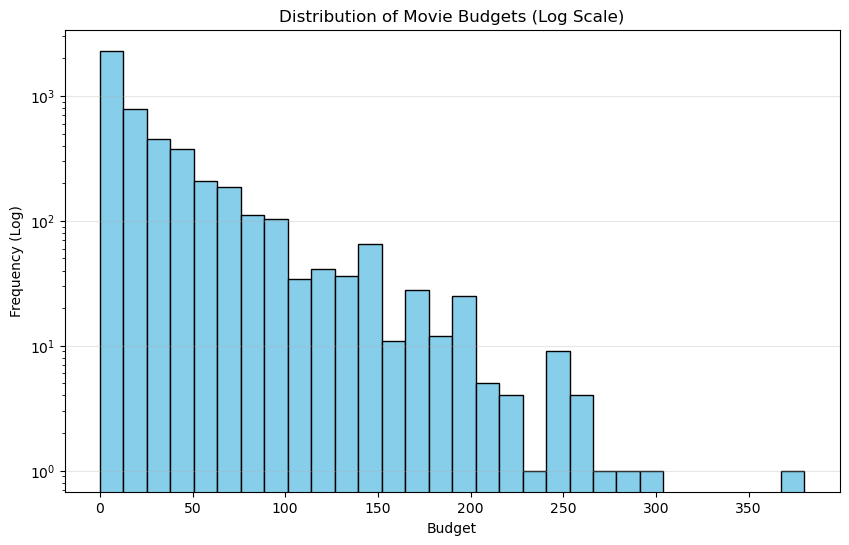

In [31]:
# Scaling data by 1,000,000 to show millions on X-axis
plt.figure(figsize=(10, 6))
plt.hist(df['budget'] / 1e6, bins=30, log=True, color='skyblue', edgecolor='black')

plt.title('Distribution of Movie Budgets (Log Scale)')
plt.xlabel('Budget')
plt.ylabel('Frequency (Log)')

plt.grid(axis='y', alpha=0.3) # Adds a light grid for better readability
plt.show()

In [ ]:
# Here we need to make 2 checks:
# - how many are the movies with budget 0
# - check if top budget movies are real

In [33]:
# See the top 20 most expensive movies to check if the numbers make sense
print(df.nlargest(20, 'budget')[['title', 'budget']])

                                              title     budget
id                                                            
1865    Pirates of the Caribbean: On Stranger Tides  380000000
285        Pirates of the Caribbean: At World's End  300000000
99861                       Avengers: Age of Ultron  280000000
1452                               Superman Returns  270000000
49529                                   John Carter  260000000
38757                                       Tangled  260000000
559                                    Spider-Man 3  258000000
57201                               The Lone Ranger  255000000
49026                         The Dark Knight Rises  250000000
767          Harry Potter and the Half-Blood Prince  250000000
209112           Batman v Superman: Dawn of Justice  250000000
122917    The Hobbit: The Battle of the Five Armies  250000000
57158           The Hobbit: The Desolation of Smaug  250000000
271110                   Captain America: Civil War  25

In [40]:
# Select top 20 movies by budget
top20 = df.nlargest(20, 'budget').copy()

# Convert budget to millions for better readability
top20['budget_m'] = top20['budget'] / 1e6

# Sort for better visual order (highest budget first)
top20 = top20.sort_values("budget_m", ascending=False)

# Create Plotly bar chart
fig = px.bar(
    top20,
    x='title',
    y='budget_m',
    title="Top 20 Highest Budget Movies",
    labels={
        "title": "Movies",
        "budget_m": "Budget (Million $)"
    }
)

# Rotate x-axis labels for readability
fig.update_layout(xaxis_tickangle=75)

# Initialize Dash app
app = Dash(__name__)

# Define layout
app.layout = html.Div([
    html.H1("Movie Budget Dashboard"),

    # Render Plotly figure inside Dash
    dcc.Graph(figure=fig)
])

# Run the server
if __name__ == "__main__":
    app.run(debug=True)

In [47]:
# Check how many are zero budget movies
zero_budget_movies = df[df['budget'] == 0]
print(f"{(len(zero_budget_movies) / len(df)) * 100:.2f}% of all movies are with zero budget")

0.00% of all movies are with zero budget


In [46]:
# 21.57% is too high percentage to be ignored. Here I see 3 ways to handle this:
# - drop this rows, but this will delete 1/5 of our data
# - fill this rows with nan
# - Data Subsetting - create new file with dropped lines with zero budget

# Here I think option 2 is the best solution. I don't want zero budget movies to manipulate final results 
df['budget'] = df['budget'].replace(0, np.nan)

In [49]:
print(df.head(2))

            budget                                    genres  \
id                                                             
19995  237000000.0  Action Adventure Fantasy Science Fiction   
285    300000000.0                  Adventure Fantasy Action   

                                           homepage  \
id                                                    
19995                   http://www.avatarmovie.com/   
285    http://disney.go.com/disneypictures/pirates/   

                                                keywords original_language  \
id                                                                           
19995  culture clash future space war space colony so...                en   
285    ocean drug abuse exotic island east india trad...                en   

                                 original_title  \
id                                                
19995                                    Avatar   
285    Pirates of the Caribbean: At World's End   

    